# StockBot: Vanilla LSTM for Stock Price Forecasting
Implements the stacked LSTM from *StockBot 2.0* (Mohanty, 2026).  
Trains a sliding-window model (60-day input → 1-day-ahead output) with Adam, MSE loss, and early stopping. At inference, the model receives the preceding 60 actual days and predicts the next day — no autoregressive feedback.

In [1]:
%pip install -q yfinance torch numpy scikit-learn matplotlib pandas

## 0. Dataset Setup
Downloads the CSV from GitHub if not available locally (e.g. on Colab).

In [2]:
import os, urllib.request

CSV_NAME   = 'aapl_daily_sentiment_2021_2025.csv'
RAW_URL    = ('https://raw.githubusercontent.com/franciscomartinez45/'
              'Stock-Forecasting-LSTM/main/data/processed/' + CSV_NAME)
LOCAL_PATHS = [f'../data/processed/{CSV_NAME}', CSV_NAME]

if not any(os.path.exists(p) for p in LOCAL_PATHS):
    print('Downloading dataset from GitHub...')
    urllib.request.urlretrieve(RAW_URL, CSV_NAME)
    print('Done.')
else:
    print('Dataset found locally.')

Done.


## 1. Imports & Config

In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

TICKER            = 'AAPL'
BASE_FEATURE      = 'close'
OPTIONAL_FEATURES = ['n_articles', 'avg_negative', 'avg_neutral', 'avg_positive']
LEAKY_COLUMNS     = ['next_close', 'next_day_pct', 'direction']
BACKTEST_MODE = 'actual'

HOLDOUT_FRAC = 0.15   # final untouched slice for the honest headline number
N_FOLDS      = 4      # expanding folds inside the remaining data
VAL_FRAC     = 0.1    # validation fraction inside each fold (except the last one, which uses the holdout)

N_TRIALS = 864
SEARCH_SPACE = {
    'hidden_dim'  : [32, 64, 128],
    'num_layers'  : [1, 2],
    'dropout'     : [0.0, 0.1, 0.3],
    'lr'          : [1e-3, 5e-4, 1e-4],
    'batch_size'  : [32, 64],
    'past_history': [30, 60],
}
MAX_EPOCHS = 60
PATIENCE   = 10
SEED       = 67

np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Data
Loads every candidate feature. Scaling is done **per fold on training rows only** (later cells), so there is no look-ahead leakage from the test period into the scaler.

In [4]:
LOCAL_CSV = next((p for p in ['../data/processed/aapl_daily_sentiment_2021_2025.csv',
                              'aapl_daily_sentiment_2021_2025.csv'] if os.path.exists(p)), None)

def load_dataframe():
    if LOCAL_CSV and TICKER == 'AAPL':
        df = pd.read_csv(LOCAL_CSV, parse_dates=['date']).sort_values('date')
        return df.reset_index(drop=True)
    raise RuntimeError('The feature search needs the sentiment CSV; yfinance only '
                       'returns OHLCV, not the sentiment columns searched over here.')

df           = load_dataframe()
ALL_FEATURES = [BASE_FEATURE] + OPTIONAL_FEATURES
dates        = df['date'].tolist()
feats        = df[ALL_FEATURES].values.astype(np.float32)   # (T, F_all)
target       = df['close'].values.astype(np.float32)        # predict NEXT-day close
n            = len(df)

print(f'{n} rows | candidate features: {ALL_FEATURES}')
print(f'Excluded as future leakage: {LEAKY_COLUMNS}')
print('Note: avg_negative+avg_neutral+avg_positive ~= 1 (collinear) -- the subset '
      'search will reveal if all three add anything.')

1160 rows | candidate features: ['close', 'n_articles', 'avg_negative', 'avg_neutral', 'avg_positive']
Excluded as future leakage: ['next_close', 'next_day_pct', 'direction']
Note: avg_negative+avg_neutral+avg_positive ~= 1 (collinear) -- the subset search will reveal if all three add anything.


## 3. Windowing, Scaling & Model
A window of `past_history` rows (across the chosen features) predicts the next day's close. Two scalers: one for the input features, one for the target close (so predictions invert back to dollars).

In [5]:
class WindowDataset(Dataset):
    """Sliding windows (past_history, n_features) -> next-day close (scalar)."""
    def __init__(self, feats_sc, target_sc, past_history):
        self.x  = torch.tensor(feats_sc,  dtype=torch.float32)
        self.y  = torch.tensor(target_sc, dtype=torch.float32)
        self.ph = past_history
    def __len__(self):  return len(self.x) - self.ph
    def __getitem__(self, i):
        return self.x[i:i + self.ph], self.y[i + self.ph]


def scale_split(feats, target, train_end, feat_idx):
    """Fit scalers on rows [:train_end] ONLY, then transform everything."""
    f_scaler  = StandardScaler().fit(feats[:train_end, feat_idx])
    t_scaler  = StandardScaler().fit(target[:train_end].reshape(-1, 1))
    feats_sc  = f_scaler.transform(feats[:, feat_idx]).astype(np.float32)
    target_sc = t_scaler.transform(target.reshape(-1, 1)).flatten().astype(np.float32)
    return feats_sc, target_sc, t_scaler


class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

## 4. Training
Adam + MSE loss with early stopping on validation loss.

In [6]:
def train_model(cfg, feats_sc, target_sc, train_end, n_features):
    """Train on [:train_end] with a VAL_FRAC tail for early stopping."""
    ph      = int(cfg['past_history'])
    bs      = int(cfg['batch_size'])
    val_cut = int(train_end * (1 - VAL_FRAC))
    train_ds = WindowDataset(feats_sc[:val_cut], target_sc[:val_cut], ph)
    val_ds   = WindowDataset(feats_sc[val_cut - ph:train_end],
                             target_sc[val_cut - ph:train_end], ph)
    if len(train_ds) < bs or len(val_ds) == 0:
        return None
    tl = DataLoader(train_ds, batch_size=bs, shuffle=True, drop_last=True)
    vl = DataLoader(val_ds,   batch_size=bs, shuffle=False)

    torch.manual_seed(SEED)
    model = StackedLSTM(n_features, int(cfg['hidden_dim']),
                        int(cfg['num_layers']), float(cfg['dropout'])).to(DEVICE)
    opt  = torch.optim.Adam(model.parameters(), lr=float(cfg['lr']))
    crit = nn.MSELoss()

    best_val, best_state, wait = float('inf'), None, 0
    for _ in range(MAX_EPOCHS):
        model.train()
        for x, y in tl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); crit(model(x), y).backward(); opt.step()
        model.eval(); v = 0.0
        with torch.no_grad():
            for x, y in vl:
                v += crit(model(x.to(DEVICE)), y.to(DEVICE)).item()
        v /= max(len(vl), 1)
        if v < best_val:
            best_val, wait = v, 0
            best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def forecast_segment(model, feats_sc, t_scaler, seg_start, seg_end, ph):
    """One-day-ahead preds for rows [seg_start, seg_end); each uses the preceding
    `ph` rows of REAL features (no autoregression)."""
    model.eval()
    out = []
    for i in range(seg_start, seg_end):
        x = torch.tensor(feats_sc[i - ph:i], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        out.append(model(x).item())
    return t_scaler.inverse_transform(np.array(out).reshape(-1, 1)).flatten()


def run_backtest(pred_prices, real_prices, mode, capital=100.0):
    """Algorithm 1 turning-point strategy.
    mode='actual'    -> signals from preds, fills at real_prices (realistic)
    mode='predicted' -> signals AND fills at pred_prices (paper, optimistic)"""
    delta = np.sign(np.diff(pred_prices)).astype(int)
    Delta = np.diff(delta)                       # +2 = local min (buy), -2 = max (sell)
    fills = real_prices if mode == 'actual' else pred_prices
    held, buy, cur, curve = False, 0.0, capital, [capital]
    for i, d in enumerate(Delta):
        px = fills[i + 1]
        if d == 2 and not held:
            held, buy = True, px
        elif d == -2 and held:
            held = False; cur *= px / buy
        curve.append(cur)
    curve.append(cur)
    return np.array(curve)

## 5. Walk-forward scoring
For one config: expanding folds over `[:eval_end]`. Each fold trains on the past, forecasts the next segment, runs the backtest, and **compounds** the portfolio into the next fold. Returns the final compounded value and mean RMSE.

In [7]:
def walk_forward_profit(cfg, feat_idx, eval_end):
    ph         = int(cfg['past_history'])
    n_features = len(feat_idx)
    seg        = eval_end // (N_FOLDS + 1)
    cur, rmses = 100.0, []
    for k in range(1, N_FOLDS + 1):
        train_end             = seg * k
        test_start, test_end  = train_end, min(seg * (k + 1), eval_end)
        if test_end - test_start <= ph + 2:
            continue
        feats_sc, target_sc, t_scaler = scale_split(feats, target, train_end, feat_idx)
        model = train_model(cfg, feats_sc, target_sc, train_end, n_features)
        if model is None:
            return None, None
        preds = forecast_segment(model, feats_sc, t_scaler, test_start, test_end, ph)
        real  = target[test_start:test_end]
        rmses.append(float(np.sqrt(np.mean((preds - real) ** 2))))
        cur = run_backtest(preds, real, BACKTEST_MODE, capital=cur)[-1]
    if not rmses:
        return None, None
    return cur, float(np.mean(rmses))

## 6. Search
Random search jointly over feature subset **and** hyperparameters (so it captures interactions). `close` is always included; each optional feature is a coin-flip. The final `HOLDOUT_FRAC` is never touched here.

In [8]:
import random
random.seed(SEED)

eval_end = int(n * (1 - HOLDOUT_FRAC))
print(f'Walk-forward window: rows 0..{eval_end} | locked holdout: {eval_end}..{n}\n')

def sample_subset():
    return [BASE_FEATURE] + [f for f in OPTIONAL_FEATURES if random.random() < 0.5]

def sample_cfg():
    return {k: random.choice(v) for k, v in SEARCH_SPACE.items()}

results, seen, trial, attempts = [], set(), 0, 0
while trial < N_TRIALS and attempts < N_TRIALS * 5:
    attempts += 1
    subset, cfg = sample_subset(), sample_cfg()
    key = (tuple(sorted(subset)), tuple(sorted(cfg.items())))
    if key in seen:
        continue
    seen.add(key)
    feat_idx = [ALL_FEATURES.index(f) for f in subset]
    profit, rmse = walk_forward_profit(cfg, feat_idx, eval_end)
    if profit is None:
        continue
    trial += 1
    results.append({'features': subset, 'n_features': len(subset),
                    'profit': profit, 'rmse': rmse, **cfg})
    print(f"[{trial:>3}/{N_TRIALS}] n_feat={len(subset)} profit=${profit:7.2f} "
          f"rmse=${rmse:5.2f} h={cfg['hidden_dim']} l={cfg['num_layers']} "
          f"do={cfg['dropout']} lr={cfg['lr']} bs={cfg['batch_size']} ph={cfg['past_history']}")

res_df = pd.DataFrame(results).sort_values('profit', ascending=False).reset_index(drop=True)
print(f'\n{len(res_df)} configs scored.')
res_df.head(10)

Walk-forward window: rows 0..986 | locked holdout: 986..1160

[  1/864] n_feat=3 profit=$ 124.74 rmse=$15.79 h=128 l=2 do=0.1 lr=0.0001 bs=64 ph=30
[  2/864] n_feat=3 profit=$ 118.20 rmse=$15.02 h=32 l=1 do=0.3 lr=0.001 bs=64 ph=60
[  3/864] n_feat=3 profit=$ 123.53 rmse=$ 8.29 h=128 l=1 do=0.0 lr=0.0005 bs=32 ph=60
[  4/864] n_feat=1 profit=$ 106.88 rmse=$ 8.63 h=64 l=1 do=0.1 lr=0.001 bs=64 ph=30
[  5/864] n_feat=4 profit=$  98.40 rmse=$14.68 h=32 l=1 do=0.3 lr=0.001 bs=64 ph=30
[  6/864] n_feat=3 profit=$ 111.44 rmse=$20.40 h=32 l=1 do=0.3 lr=0.0001 bs=32 ph=60
[  7/864] n_feat=5 profit=$ 119.43 rmse=$ 8.37 h=64 l=2 do=0.0 lr=0.001 bs=32 ph=60
[  8/864] n_feat=3 profit=$ 129.13 rmse=$17.51 h=64 l=2 do=0.3 lr=0.0001 bs=64 ph=30
[  9/864] n_feat=2 profit=$ 172.24 rmse=$19.24 h=64 l=1 do=0.0 lr=0.0001 bs=64 ph=60
[ 10/864] n_feat=1 profit=$ 110.40 rmse=$20.90 h=32 l=2 do=0.3 lr=0.0001 bs=64 ph=30
[ 11/864] n_feat=3 profit=$ 170.41 rmse=$11.13 h=32 l=2 do=0.3 lr=0.0005 bs=32 ph=30
[ 12/

,features,n_features,profit,rmse,hidden_dim,num_layers,dropout,lr,batch_size,past_history
0,"[close, n_articles, avg_negative, avg_neutral,...",5,191.326370,10.417295,32,2,0.0,0.0010,32,60
1,"[close, avg_negative]",2,190.784031,8.403432,128,2,0.1,0.0001,32,30
2,"[close, avg_negative]",2,185.585565,8.689781,64,2,0.0,0.0010,32,30
3,"[close, avg_neutral, avg_positive]",3,184.374950,11.267415,32,2,0.3,0.0005,32,60
4,"[close, avg_negative, avg_neutral]",3,184.101035,10.342215,32,2,0.1,0.0010,32,30
5,"[close, avg_negative]",2,183.697600,10.271698,64,2,0.3,0.0005,32,60
6,"[close, n_articles, avg_neutral]",3,183.159373,14.444582,32,1,0.0,0.0010,64,60
7,"[close, n_articles, avg_neutral]",3,182.047089,16.584708,32,1,0.1,0.0005,64,30
8,"[close, n_articles, avg_negative, avg_neutral,...",5,180.291359,9.457372,128,2,0.3,0.0005,64,60
9,"[close, avg_negative, avg_neutral]",3,180.223830,10.392124,32,2,0.0,0.0010,32,30


## 7. Which / how many features? Which hyperparameters?
The left plot answers *"optimal number of features"* directly. The right plot is the cautionary one: lower RMSE does **not** reliably mean more profit.

Best config by walk-forward profit:
features        [close, n_articles, avg_negative, avg_neutral,...
n_features                                                      5
profit                                                  191.32637
rmse                                                    10.417295
hidden_dim                                                     32
num_layers                                                      2
dropout                                                       0.0
lr                                                          0.001
batch_size                                                     32
past_history                                                   60

Profit by number of features:
                   max        mean  count
n_features                               
1           167.618373  128.231401     49
2           190.784031  126.653996    228
3           184.374950  122.717957    292
4           178.773149  115.376688    236
5           191.32637

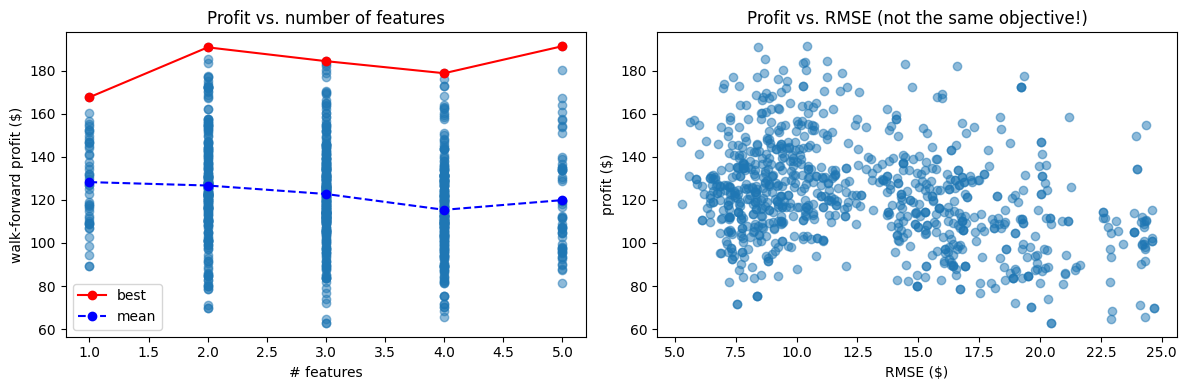

In [9]:
os.makedirs('plots', exist_ok=True)
best = res_df.iloc[0]
print('Best config by walk-forward profit:')
print(best[['features', 'n_features', 'profit', 'rmse', 'hidden_dim', 'num_layers',
            'dropout', 'lr', 'batch_size', 'past_history']].to_string())

by_k = res_df.groupby('n_features')['profit'].agg(['max', 'mean', 'count'])
print('\nProfit by number of features:'); print(by_k.to_string())

feat_rate = (pd.Series({f: res_df[res_df['features'].apply(lambda s: f in s)]['profit'].mean()
                        for f in OPTIONAL_FEATURES}).sort_values(ascending=False))
print('\nMean profit of configs that INCLUDE each optional feature:')
print(feat_rate.to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(res_df['n_features'], res_df['profit'], alpha=.5)
ax[0].plot(by_k.index, by_k['max'],  'r-o', label='best')
ax[0].plot(by_k.index, by_k['mean'], 'b--o', label='mean')
ax[0].set_xlabel('# features'); ax[0].set_ylabel('walk-forward profit ($)')
ax[0].set_title('Profit vs. number of features'); ax[0].legend()
ax[1].scatter(res_df['rmse'], res_df['profit'], alpha=.5)
ax[1].set_xlabel('RMSE ($)'); ax[1].set_ylabel('profit ($)')
ax[1].set_title('Profit vs. RMSE (not the same objective!)')
plt.tight_layout(); plt.savefig('plots/search_summary.png', dpi=150); plt.show()

## 8. Honest final number — locked holdout
Retrain the single best config on all pre-holdout data and evaluate **once** on the locked holdout. Benchmarks: **buy & hold** (what you'd get doing nothing) and the **oracle** (perfect foresight ceiling).

/tmp/ipykernel_1739/2135814713.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best['featues'] = ['close']
/tmp/ipykernel_1739/2135814713.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best['featues'] = ['close']


Features:               ['close', 'n_articles', 'avg_negative', 'avg_neutral', 'avg_positive']
Holdout RMSE:           $15.54
Strategy (actual) final: $122.11
Buy & hold final:       $135.46
Oracle (perfect) final: $281.73


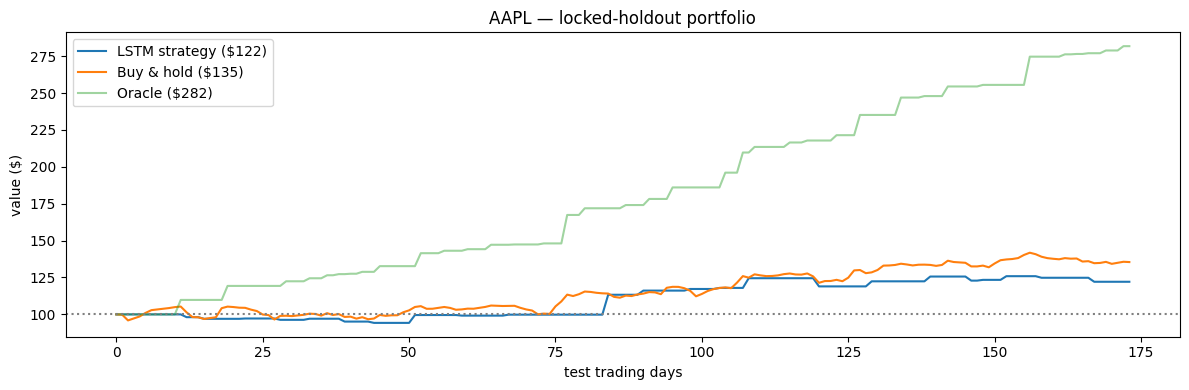

In [10]:
best_cfg    = {k: best[k] for k in SEARCH_SPACE}
best_subset = list(best['features'])
feat_idx    = [ALL_FEATURES.index(f) for f in best_subset]
ph          = int(best_cfg['past_history'])
best['featues'] = ['close']
feats_sc, target_sc, t_scaler = scale_split(feats, target, eval_end, feat_idx)
model = train_model(best_cfg, feats_sc, target_sc, eval_end, len(feat_idx))

preds = forecast_segment(model, feats_sc, t_scaler, eval_end, n, ph)
real  = target[eval_end:]
rmse  = float(np.sqrt(np.mean((preds - real) ** 2)))

strat   = run_backtest(preds, real, BACKTEST_MODE)
oracle  = run_backtest(real,  real, 'predicted')
buyhold = 100.0 * real / real[0]

print(f'Features:               {best_subset}')
print(f'Holdout RMSE:           ${rmse:.2f}')
print(f'Strategy ({BACKTEST_MODE}) final: ${strat[-1]:.2f}')
print(f'Buy & hold final:       ${buyhold[-1]:.2f}')
print(f'Oracle (perfect) final: ${oracle[-1]:.2f}')

plt.figure(figsize=(12, 4))
plt.plot(strat,   label=f'LSTM strategy (${strat[-1]:.0f})')
plt.plot(buyhold, label=f'Buy & hold (${buyhold[-1]:.0f})')
plt.plot(oracle,  label=f'Oracle (${oracle[-1]:.0f})', alpha=.45)
plt.axhline(100, color='gray', ls=':')
plt.title(f'{TICKER} — locked-holdout portfolio'); plt.legend()
plt.xlabel('test trading days'); plt.ylabel('value ($)')
plt.tight_layout(); plt.savefig(f'plots/{TICKER}_holdout_portfolio.png', dpi=150); plt.show()

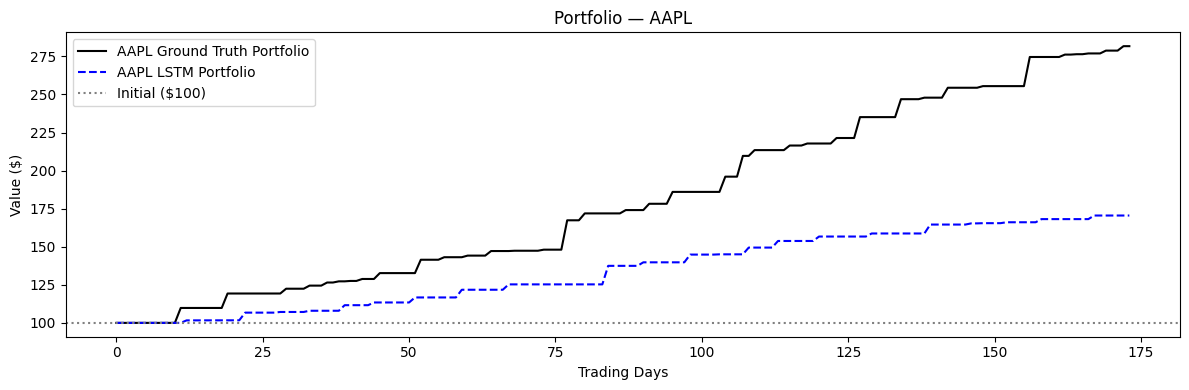

LSTM portfolio final value:         $170.51
Ground truth portfolio final value: $281.73


In [12]:
def stockbot_portfolio(prices, capital=100.0):
    delta = np.sign(np.diff(prices)).astype(int)   # direction of change
    Delta = np.diff(delta)                          # curvature
    held, buy_price, cur = False, 0.0, capital
    portfolio = [cur]
    for i, d in enumerate(Delta):
        signal_price = prices[i + 1]
        if d == 2 and not held:        # local min -> buy
            held, buy_price = True, signal_price
        elif d == -2 and held:         # local max -> sell
            held = False
            cur *= signal_price / buy_price
        portfolio.append(cur)
    portfolio.append(cur)              # final day
    return np.array(portfolio)

# §8 produced `preds` (LSTM holdout forecast) and `real` (actual holdout close).
# The original snippet called the ground-truth series `actual`; map it here.
actual = real

lstm_port = stockbot_portfolio(preds)
gt_port   = stockbot_portfolio(actual)

os.makedirs('plots', exist_ok=True)
plt.figure(figsize=(12, 4))
plt.plot(gt_port,   color='black', label=f'{TICKER} Ground Truth Portfolio', linewidth=1.5)
plt.plot(lstm_port, color='blue',  label=f'{TICKER} LSTM Portfolio',         linestyle='--')
plt.axhline(100, color='gray', linestyle=':', label='Initial ($100)')
plt.ticklabel_format(useOffset=False, style='plain')
plt.title(f'Portfolio — {TICKER}')
plt.xlabel('Trading Days'); plt.ylabel('Value ($)'); plt.legend()
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_portfolio.png', dpi=150)
plt.show()

print(f'LSTM portfolio final value:         ${lstm_port[-1]:.2f}')
print(f'Ground truth portfolio final value: ${gt_port[-1]:.2f}')